In [ ]:
!pip install pyomo

In [ ]:
!apt-get install -y glpk-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libamd2 libcolamd2 libglpk40 libsuitesparseconfig5
Suggested packages:
  libiodbc2-dev
The following NEW packages will be installed:
  glpk-utils libamd2 libcolamd2 libglpk40 libsuitesparseconfig5
0 upgraded, 5 newly installed, 0 to remove and 41 not upgraded.
Need to get 625 kB of archives.
After this operation, 2,158 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsuitesparseconfig5 amd64 1:5.10.1+dfsg-4build1 [10.4 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libamd2 amd64 1:5.10.1+dfsg-4build1 [21.6 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libcolamd2 amd64 1:5.10.1+dfsg-4build1 [18.0 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libglpk40 amd64 5.0-1 [361 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 glpk-ut

In [ ]:
!apt-get install -y coinor-cbc


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  coinor-libcbc3 coinor-libcgl1 coinor-libclp1 coinor-libcoinutils3v5
  coinor-libosi1v5
The following NEW packages will be installed:
  coinor-cbc coinor-libcbc3 coinor-libcgl1 coinor-libclp1
  coinor-libcoinutils3v5 coinor-libosi1v5
0 upgraded, 6 newly installed, 0 to remove and 41 not upgraded.
Need to get 2,908 kB of archives.
After this operation, 8,310 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libcoinutils3v5 amd64 2.11.4+repack1-2 [465 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libosi1v5 amd64 0.108.6+repack1-2 [275 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libclp1 amd64 1.17.5+repack1-1 [937 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libcgl1 amd64 0.60.3+repack1-3 [420 kB]
Get:5 ht

In [ ]:
!cbc --version

522

Welcome to the CBC MILP Solver 
Version: 2.10.7 
Build Date: Feb 14 2022 

command line - cbc --version (default strategy 1)
No match for -version - ? for list of commands
CoinSolver takes input from arguments ( - switches to stdin)
Enter ? for list of commands or help
Coin:^C


522

In [ ]:
!glpsol --version


/bin/bash: line 1: glpsol: command not found


In [ ]:
!pip install gurobipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 73.3 MB/s eta 0:00:00


**creation des fichiers**

In [ ]:
import json
import random
import math

def generate_vrp_json_powerful(
    filename="vrp_powerfl.json",
    num_clients=20,
    num_vehicles=7,
    vehicle_capacity=10,
    depot_coord=(0.0, 0.0),
    service_time_range=(5, 15),
    coord_range=(-50.0, 50.0),
    demand_range=(5, 12),
    rng_seed=None
):

    if rng_seed is not None:
        random.seed(rng_seed)

    depot_x, depot_y = depot_coord


    clients = []
    for i in range(1, num_clients + 1):

        x = round(random.uniform(coord_range[0], coord_range[1]), 2)
        y = round(random.uniform(coord_range[0], coord_range[1]), 2)


        dist = math.hypot(x - depot_x, y - depot_y)


        client_demand = random.randint(demand_range[0], demand_range[1])

        service_time = random.randint(service_time_range[0], service_time_range[1])


        ready = int(dist * 5) + random.randint(0, 10)


        est_travel_time = int(dist * 3)


        buffer = max(60, int(client_demand * 5 + random.randint(20, 50)))

        due = ready + est_travel_time + service_time + buffer

        clients.append({
            "id": i,
            "x": x,
            "y": y,
            "demand": client_demand,
            "ready_time": ready,
            "due_time": due,
            "service_time": service_time
        })


    total_demand = sum(c["demand"] for c in clients)
    total_capacity = num_vehicles * vehicle_capacity
    if total_demand > total_capacity:

        vehicle_capacity = math.ceil(total_demand / num_vehicles * 1.2)
        print(f"Adjusted vehicle_capacity to {vehicle_capacity} to fit total demand {total_demand}")

    data = {
        "num_vehicles": num_vehicles,
        "vehicle_capacity": vehicle_capacity,
        "depot": 0,
        "depot_coord": {"x": depot_x, "y": depot_y},
        "clients": clients,
        "distance_type": "euclidean"
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Generated powerful VRP file: {filename}")
    print(f"  num_clients = {num_clients}, num_vehicles = {num_vehicles}, vehicle_capacity = {vehicle_capacity}")
    avg_window = sum((c["due_time"] - c["ready_time"]) for c in clients) / len(clients)
    print(f"  avg_time_window = {avg_window:.1f}")

    return data


generate_vrp_json_powerful(
    filename="vrp500.json",
    num_clients=500,
    num_vehicles=10,
    vehicle_capacity=10,
    rng_seed=42
)


Adjusted vehicle_capacity to 522 to fit total demand 4342
Generated powerful VRP file: vrp500.json
  num_clients = 500, num_vehicles = 10, vehicle_capacity = 522
  avg_time_window = 205.6


{'num_vehicles': 10,
 'vehicle_capacity': 522,
 'depot': 0,
 'depot_coord': {'x': 0.0, 'y': 0.0},
 'clients': [{'id': 1,
   'x': 13.94,
   'y': -47.5,
   'demand': 9,
   'ready_time': 250,
   'due_time': 475,
   'service_time': 8},
  {'id': 2,
   'x': 23.65,
   'y': 17.67,
   'demand': 6,
   'ready_time': 153,
   'due_time': 315,
   'service_time': 14},
  {'id': 3,
   'x': -47.02,
   'y': -28.14,
   'demand': 5,
   'ready_time': 276,
   'due_time': 520,
   'service_time': 13},
  {'id': 4,
   'x': 14.99,
   'y': 4.49,
   'demand': 8,
   'ready_time': 87,
   'due_time': 213,
   'service_time': 12},
  {'id': 5,
   'x': 30.94,
   'y': -49.35,
   'demand': 7,
   'ready_time': 296,
   'due_time': 544,
   'service_time': 11},
  {'id': 6,
   'x': -34.45,
   'y': 45.72,
   'demand': 10,
   'ready_time': 287,
   'due_time': 546,
   'service_time': 6},
  {'id': 7,
   'x': -40.33,
   'y': 34.75,
   'demand': 9,
   'ready_time': 273,
   'due_time': 519,
   'service_time': 5},
  {'id': 8,
   'x': -3

**la modélisations**

In [ ]:

import json
import math
import pyomo.environ as pyo
from pyomo.environ import ConcreteModel, Set, RangeSet, Var, Binary, NonNegativeReals, Objective, Constraint, minimize, value
import time

In [ ]:


filename = "vrp500.json"

with open(filename, "r") as f:
    data = json.load(f)

num_vehicles = data["num_vehicles"]
vehicle_capacity = data["vehicle_capacity"]
depot = data["depot"]
clients = data["clients"]
nodes = [depot] + [c["id"] for c in clients]

print("Num vehicles:", num_vehicles)
print("Vehicle capacity:", vehicle_capacity)
print("Clients:")
for c in clients:
    print(f"  ID {c['id']}, Demand {c['demand']}, Time window [{c['ready_time']}, {c['due_time']}]")

Num vehicles: 10
Vehicle capacity: 522
Clients:
  ID 1, Demand 9, Time window [250, 475]
  ID 2, Demand 6, Time window [153, 315]
  ID 3, Demand 5, Time window [276, 520]
  ID 4, Demand 8, Time window [87, 213]
  ID 5, Demand 7, Time window [296, 544]
  ID 6, Demand 10, Time window [287, 546]
  ID 7, Demand 9, Time window [273, 519]
  ID 8, Demand 6, Time window [286, 544]
  ID 9, Demand 10, Time window [206, 433]
  ID 10, Demand 9, Time window [232, 467]
  ID 11, Demand 10, Time window [233, 457]
  ID 12, Demand 6, Time window [196, 381]
  ID 13, Demand 12, Time window [132, 329]
  ID 14, Demand 10, Time window [78, 224]
  ID 15, Demand 9, Time window [254, 504]
  ID 16, Demand 10, Time window [300, 567]
  ID 17, Demand 12, Time window [217, 436]
  ID 18, Demand 9, Time window [136, 321]
  ID 19, Demand 7, Time window [87, 208]
  ID 20, Demand 7, Time window [223, 450]
  ID 21, Demand 11, Time window [111, 272]
  ID 22, Demand 5, Time window [236, 458]
  ID 23, Demand 10, Time window 

In [ ]:


demand = {c["id"]: c["demand"] for c in clients}
demand[depot] = 0

coords = {c["id"]: (c["x"], c["y"]) for c in clients}
coords[depot] = (data["depot_coord"]["x"], data["depot_coord"]["y"])

service_time = {c["id"]: c["service_time"] for c in clients}
service_time[depot] = 0



def distance(i, j):
    xi, yi = coords[i]
    xj, yj = coords[j]
    return math.hypot(xi - xj, yi - yj)

dist = {(i,j): distance(i,j) for i in nodes for j in nodes if i != j}


In [ ]:
def create_and_solve_vrp(nodes, depot, demand, dist, vehicle_capacity, service_time=None, ready_time=None, due_time=None):

    model = ConcreteModel()
    num_vehicles = max(1, len(nodes) // 5)
    model.N = Set(initialize=nodes)
    model.K = RangeSet(0, num_vehicles-1)


    model.x = Var(model.N, model.N, model.K, domain=Binary)
    model.u = Var(model.N, domain=NonNegativeReals)
    if service_time and ready_time and due_time:
        model.t = Var(model.N, domain=NonNegativeReals)


    model.obj = Objective(
        expr=sum(dist[i,j]*model.x[i,j,k] for i in nodes for j in nodes if i != j for k in model.K),
        sense=minimize
    )



    # Chaque client est visité exactement une fois
    def visit_once_rule(model, j):
        if j == depot:
            return Constraint.Skip
        return sum(model.x[i,j,k] for i in nodes if i != j for k in model.K) == 1
    model.visit_once = Constraint(model.N, rule=visit_once_rule)

    # Conservation du flux pour chaque véhicule
    def flow_rule(model, k, i):
        if i == depot:
            return Constraint.Skip
        return sum(model.x[i,j,k] for j in nodes if j != i) - sum(model.x[j,i,k] for j in nodes if j != i) == 0
    model.flow = Constraint(model.K, model.N, rule=flow_rule)

    # Chaque véhicule part du dépôt au maximum une fois
    def depart_depot_rule(model, k):
        return sum(model.x[depot,j,k] for j in nodes if j != depot) <= 1
    model.depart_depot = Constraint(model.K, rule=depart_depot_rule)


    # Capacités des véhicules(cvrp)
    def capacity_rule(model, k):
        return sum(demand[j]*model.x[i,j,k] for i in nodes for j in nodes if i != j) <= vehicle_capacity
    model.capacity = Constraint(model.K, rule=capacity_rule)

    # Sous-tours interdits (MTZ)
    def mtz_rule(model, i, j, k):
        if i == j or i == depot or j == depot:
            return Constraint.Skip
        return model.u[i] - model.u[j] + vehicle_capacity*model.x[i,j,k] <= vehicle_capacity - demand[j]
    model.mtz = Constraint(model.N, model.N, model.K, rule=mtz_rule)

    # 4) Contraintes temporelles si données fournies (VRPTW)
    if service_time and ready_time and due_time:

        def time_window_rule(model, i, j, k):
            if i == j:
                return Constraint.Skip
            return model.t[i] + service_time[i] + dist[i,j] <= model.t[j] + (1 - model.x[i,j,k])*10000
        model.time_window = Constraint(model.N, model.N, model.K, rule=time_window_rule)


        def arrival_window_rule(model, i):
            return pyo.inequality(ready_time[i], model.t[i], due_time[i])
        model.arrival_window = Constraint(model.N, rule=arrival_window_rule)


    return model

In [ ]:

model = create_and_solve_vrp(nodes, depot, demand, dist, vehicle_capacity, service_time , ready_time , due_time)

solver = pyo.SolverFactory('glpk')  #  'cbc'/ 'glpk'

start_time = time.time()
results = solver.solve(model, tee=True)
end_time = time.time()

solver_time = end_time - start_time
total_distance = pyo.value(model.obj)

print("Status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)
print("Temps de résolution du solver (s):", solver_time)
print("Distance totale (objective value):", total_distance)

In [ ]:
#route extraction

from collections import deque

def extract_routes_bfs(model, nodes, depot):
    routes = {}

    for k in model.K:

        graph = {i: [] for i in nodes}


        for i in nodes:
            for j in nodes:
                if i != j and pyo.value(model.x[i, j, k]) > 0.5:
                    graph[i].append(j)


        visited = set()
        queue = deque([depot])
        route = [depot]

        while queue:
            current = queue.popleft()
            visited.add(current)


            for nxt in graph[current]:
                if nxt not in visited:
                    route.append(nxt)
                    queue.append(nxt)


        if len(route) > 1:
            route.append(depot)

        routes[k] = route

    return routes

routes = extract_routes_bfs(model, nodes, depot)

for k in routes:
    print(f"Route for vehicle {k}: {routes[k]}")

**les strategies**

**strategiers 1**

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from math import ceil
import pyomo.environ as pyo



In [ ]:

num_clusters = 3
client_coords = np.array([coords[c['id']] for c in clients])
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(client_coords)
labels = kmeans.labels_
clusters = {i: [] for i in range(num_clusters)}
for idx, label in enumerate(labels):
    clusters[label].append(clients[idx]['id'])
for cluster_id, cluster_clients in clusters.items():
    print(f"\n=== Cluster {cluster_id}, clients: {cluster_clients} ===")


=== Cluster 0, clients: [3, 11, 12, 15, 18] ===

=== Cluster 1, clients: [1, 2, 4, 5, 9, 13, 14, 16, 19, 20] ===

=== Cluster 2, clients: [6, 7, 8, 10, 17] ===


In [ ]:

demand = {c["id"]: c["demand"] for c in data["clients"]}
service_time = {c["id"]: c["service_time"] for c in data["clients"]}
ready_time = {c["id"]: c["ready_time"] for c in data["clients"]}
due_time = {c["id"]: c["due_time"] for c in data["clients"]}
coords = {c["id"]: (c["x"], c["y"]) for c in data["clients"]}
depot = data["depot"]


def distance(i, j):
    if i == depot:
        x1, y1 = data["depot_coord"]["x"], data["depot_coord"]["y"]
    else:
        x1, y1 = coords[i]
    if j == depot:
        x2, y2 = data["depot_coord"]["x"], data["depot_coord"]["y"]
    else:
        x2, y2 = coords[j]
    return math.hypot(x1 - x2, y1 - y2)


In [ ]:

cluster_solutions = {}

for cluster_id, cluster_clients in clusters.items():
    print(f"\n=== Cluster {cluster_id}, clients: {cluster_clients} ===")


    cluster_nodes = [depot] + cluster_clients

    cluster_demand = {c: demand[c] for c in cluster_clients}
    cluster_demand[depot] = 0

    cluster_service_time = {c: service_time[c] for c in cluster_clients}
    cluster_service_time[depot] = 0

    cluster_ready_time = {c: ready_time[c] for c in cluster_clients}
    cluster_ready_time[depot] = 0

    cluster_due_time = {c: due_time[c] for c in cluster_clients}
    cluster_due_time[depot] = 1e6


    total_demand = sum(cluster_demand[c] for c in cluster_nodes if c != depot)
    num_vehicles_cluster = ceil(total_demand / vehicle_capacity)
    print(f"Nombre de véhicules nécessaires: {num_vehicles_cluster}")

    cluster_dist = {(i,j): distance(i,j) for i in cluster_nodes for j in cluster_nodes if i != j}


=== Cluster 0, clients: [3, 11, 12, 15, 18] ===
Nombre de véhicules nécessaires: 2

=== Cluster 1, clients: [1, 2, 4, 5, 9, 13, 14, 16, 19, 20] ===
Nombre de véhicules nécessaires: 5

=== Cluster 2, clients: [6, 7, 8, 10, 17] ===
Nombre de véhicules nécessaires: 3


In [ ]:
model_cluster = create_and_solve_vrp(
    nodes=cluster_nodes,
    depot=depot,
    demand=cluster_demand,
    dist=cluster_dist,
    vehicle_capacity=vehicle_capacity,
    service_time=cluster_service_time,
    ready_time=cluster_ready_time,
    due_time=cluster_due_time
)

solver = pyo.SolverFactory('glpk')  # أو 'cbc', 'gurobi'
results = solver.solve(model_cluster, tee=True)


if results.solver.termination_condition == pyo.TerminationCondition.optimal:
    total_distance = pyo.value(model_cluster.obj)
    print(f"Distance totale: {total_distance}")
else:
    print("Solver n'a pas trouvé de solution faisable pour ce cluster")


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpylp2rt_x.glpk.raw --wglp /tmp/tmpmrzcuwvg.glpk.glp --cpxlp
 /tmp/tmp3al9rx5a.pyomo.lp
Reading problem data from '/tmp/tmp3al9rx5a.pyomo.lp'...
/tmp/tmp3al9rx5a.pyomo.lp:578: warning: lower bound of variable 'x2' redefined
/tmp/tmp3al9rx5a.pyomo.lp:578: warning: upper bound of variable 'x2' redefined
75 rows, 41 columns, 272 non-zeros
30 integer variables, all of which are binary
608 lines were read
Writing problem data to '/tmp/tmpmrzcuwvg.glpk.glp'...
502 lines were written
GLPK Integer Optimizer 5.0
75 rows, 41 columns, 272 non-zeros
30 integer variables, all of which are binary
Preprocessing...
25 constraint coefficient(s) were reduced
63 rows, 41 columns, 260 non-zeros
30 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+04  ratio =  1.000e+04
GM: min|aij| =  4.780e-01  max|aij| =  2.092e+00  ratio =  4.376e+00
EQ: min|aij| =  2.331e-01  max|

par capacity
CAPACITATED K-MEANS CLUSTERING

In [ ]:
import math
import numpy as np
from sklearn.cluster import KMeans



def capacitated_clustering(clients, vehicle_capacity, depot, coords, demand, n_vehicles):
    """
    Retourne une liste de clusters, chaque cluster = liste des client.id
    Respecte la contrainte : somme(demandes) ≤ capacité du véhicule
    """


    client_ids = [c["id"] for c in clients]
    X = np.array([coords[c] for c in client_ids])


    kmeans = KMeans(n_clusters=n_vehicles, random_state=0)
    labels = kmeans.fit_predict(X)


    clusters = {k: [] for k in range(n_vehicles)}
    for cid, lab in zip(client_ids, labels):
        clusters[lab].append(cid)


    def cluster_demand(cluster):
        return sum(demand[c] for c in cluster)

    overloaded = True
    while overloaded:
        overloaded = False

        for k in range(n_vehicles):
            while cluster_demand(clusters[k]) > vehicle_capacity:
                overloaded = True


                cid_to_move = max(clusters[k], key=lambda c: demand[c])
                clusters[k].remove(cid_to_move)


                best_cluster = None
                best_dist = float("inf")

                for kk in range(n_vehicles):
                    if kk == k:
                        continue
                    if cluster_demand(clusters[kk]) + demand[cid_to_move] <= vehicle_capacity:

                        cx, cy = kmeans.cluster_centers_[kk]
                        px, py = coords[cid_to_move]
                        d = math.hypot(cx - px, cy - py)
                        if d < best_dist:
                            best_dist = d
                            best_cluster = kk


                if best_cluster is None:
                    for kk in range(n_vehicles):
                        if cluster_demand(clusters[kk]) + demand[cid_to_move] <= vehicle_capacity:
                            best_cluster = kk
                            break

                clusters[best_cluster].append(cid_to_move)

    return clusters


In [ ]:

n_vehicles = num_vehicles


clusters = capacitated_clustering(
    clients=clients,
    vehicle_capacity=vehicle_capacity,
    depot=depot,
    coords=coords,
    demand=demand,
    n_vehicles=n_vehicles
)

print("\n--- CLUSTERS OBTENUS ---")
for k, c in clusters.items():
    print(f"Vehicule {k} : {c} (Total demand = {sum(demand[i] for i in c)})")



--- CLUSTERS OBTENUS ---
Vehicule 0 : [35, 40, 52, 63, 81, 93, 94, 114, 116, 119, 121, 131, 144, 148, 161, 162, 164, 176, 193, 215, 223, 225, 229, 231, 239, 248, 251, 256, 270, 275, 291, 297, 300, 306, 312, 314, 341, 359, 378, 381, 395, 399, 407, 414, 418, 429, 463, 470, 471, 498] (Total demand = 448)
Vehicule 1 : [2, 16, 20, 23, 25, 28, 42, 45, 53, 66, 76, 82, 85, 88, 92, 97, 99, 107, 140, 155, 165, 170, 172, 179, 197, 200, 201, 202, 204, 242, 244, 246, 253, 261, 266, 274, 279, 295, 317, 339, 345, 346, 353, 367, 368, 387, 389, 391, 396, 397, 404, 412, 422, 427, 443, 464, 481, 485, 496, 497] (Total demand = 481)
Vehicule 2 : [6, 7, 8, 39, 49, 54, 55, 56, 64, 69, 84, 106, 108, 124, 136, 157, 158, 168, 182, 187, 189, 194, 195, 212, 227, 264, 272, 276, 277, 281, 284, 305, 324, 330, 331, 338, 342, 348, 358, 363, 384, 400, 420, 421, 426, 434, 435, 445, 479, 491, 494, 499] (Total demand = 437)
Vehicule 3 : [1, 5, 29, 48, 51, 61, 72, 73, 79, 86, 89, 113, 130, 147, 167, 180, 185, 186, 199, 20

In [ ]:
solutions = {}

for k in clusters:
    cluster_nodes = [depot] + clusters[k]

    print(f"\n=== Résolution VRP pour véhicule {k} ===")

    model = create_and_solve_vrp(
        nodes=cluster_nodes,
        depot=depot,
        demand=demand,
        dist=dist,
        vehicle_capacity=vehicle_capacity,
        service_time=service_time
    )

    solver = pyo.SolverFactory("glpk")
    results = solver.solve(model, tee=False)

    solutions[k] = {
        "status": results.solver.status,
        "termination": results.solver.termination_condition,
        "objective": pyo.value(model.obj)
    }

    print(solutions[k])



=== Résolution VRP pour véhicule 0 ===


**stratégie 2**

In [ ]:

coords = {c["id"]: (c["x"], c["y"]) for c in clients}


coords[depot] = (data["depot_coord"]["x"], data["depot_coord"]["y"])

def distance(i, j):
    xi, yi = coords[i]
    xj, yj = coords[j]
    return np.hypot(xi - xj, yi - yj)


nodes_clients = [c['id'] for c in clients]
all_nodes = [depot] + nodes_clients

distances = {(i,j): distance(i,j) for i in all_nodes for j in all_nodes if i != j}


In [ ]:
unvisited = set(nodes_clients)
route_first = [depot]
current = depot

while unvisited:
    next_node = min(unvisited, key=lambda x: distances[(current,x)])
    route_first.append(next_node)
    unvisited.remove(next_node)
    current = next_node

route_first.append(depot)
print("Route-First (glouton):", route_first)

Route-First (glouton): [0, 14, 4, 21, 2, 23, 28, 16, 25, 20, 9, 22, 17, 6, 8, 7, 10, 30, 18, 26, 12, 11, 15, 27, 3, 24, 29, 1, 5, 13, 19, 0]


In [ ]:

clusters = []
current_cluster = []
current_load = 0

for node in route_first[1:-1]:
    if current_load + demand[node] <= vehicle_capacity:
        current_cluster.append(node)
        current_load += demand[node]
    else:
        clusters.append(current_cluster)
        current_cluster = [node]
        current_load = demand[node]

if current_cluster:
    clusters.append(current_cluster)

In [ ]:
cluster_solutions = {}
total_global_distance = 0

for idx, cluster_nodes in enumerate(clusters):
    cluster_nodes_with_depot = [depot] + cluster_nodes
    cluster_demand = {c: demand[c] for c in cluster_nodes_with_depot}
    cluster_dist = {(i,j): distance(i,j) for i in cluster_nodes_with_depot for j in cluster_nodes_with_depot if i != j}

    model_cluster = create_and_solve_vrp(
        nodes=cluster_nodes_with_depot,
        depot=depot,
        demand=cluster_demand,
        dist=cluster_dist,
        vehicle_capacity=vehicle_capacity
    )

    solver = pyo.SolverFactory('gurobi')
    results = solver.solve(model_cluster, tee=False)

    if results.solver.termination_condition == pyo.TerminationCondition.optimal:
        total_distance = pyo.value(model_cluster.obj)
        total_global_distance += total_distance
        status = results.solver.status
    else:
        total_distance = None
        status = results.solver.status

    cluster_solutions[idx] = {
        "model": model_cluster,
        "distance": total_distance,
        "status": status
    }

    print(f"Cluster {idx}, clients: {cluster_nodes}, Distance: {total_distance}, Status: {status}")


print("\n=== Distance Totale de Tous les Clusters :", total_global_distance, "===\n")


Cluster 0, clients: [14, 4, 21], Distance: 42.40792410021775, Status: ok
Cluster 1, clients: [2, 23, 28], Distance: 115.0192430457939, Status: ok
Cluster 2, clients: [16, 25, 20], Distance: 121.17116533779728, Status: ok
Cluster 3, clients: [9, 22, 17], Distance: 111.00865434852147, Status: ok
Cluster 4, clients: [6, 8, 7], Distance: 123.1206587107144, Status: ok
Cluster 5, clients: [10, 30, 18], Distance: 92.70915681557142, Status: ok
Cluster 6, clients: [26, 12, 11], Distance: 94.4936398315002, Status: ok
Cluster 7, clients: [15, 27, 3, 24], Distance: 149.89938863697205, Status: ok
Cluster 8, clients: [29, 1, 5], Distance: 126.9911758276688, Status: ok
Cluster 9, clients: [13, 19], Distance: 54.59493805956055, Status: ok

=== Distance Totale de Tous les Clusters : 1031.415944714318 ===



Visualisation

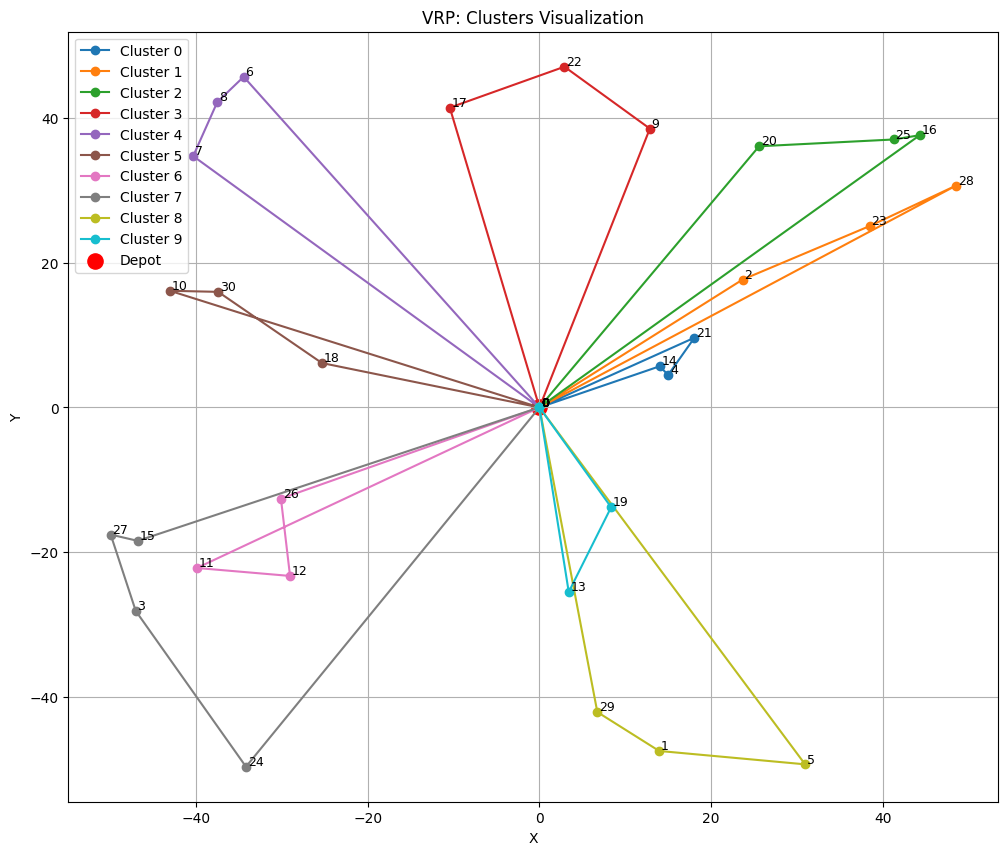

In [ ]:

import matplotlib.pyplot as plt

colors = plt.cm.tab10.colors
plt.figure(figsize=(12,10))

for idx, cluster_nodes in enumerate(clusters):
    route = [depot] + cluster_nodes + [depot]
    x = [coords[n][0] for n in route]
    y = [coords[n][1] for n in route]
    plt.plot(x, y, marker='o', color=colors[idx % 10], label=f'Cluster {idx}')
    for n in route:
        plt.text(coords[n][0]+0.2, coords[n][1]+0.2, str(n), fontsize=9)

plt.scatter(coords[depot][0], coords[depot][1], c='red', s=120, label='Depot')
plt.title("VRP: Clusters Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

**visualisation**